# M2PO — Second-Moment Trust Policy Optimization (toy kernel)

Paper: *Prosperity before Collapse: How Far Can Off-Policy RL Reach with Stale Data on LLMs?* ([arXiv:2510.01161](https://arxiv.org/abs/2510.01161))

**Problem.** Off-policy / stale rollouts create a distribution gap between the behavior policy $\pi_{\text{behav}}$ that generated the data and the current $\pi_\theta$. PPO/GRPO control this with $\epsilon$-clipping, but under heavy staleness clipping silences *many* high-entropy tokens — exactly the informative ones — and performance degrades.

**Idea.** Replace per-token $\epsilon$-clipping with a **batch-level trust region on the second moment of the log importance ratio**:

$$\hat M_2 = \frac{1}{N}\sum_i (\log r_i)^2,\qquad r_i = \frac{\pi_\theta(a_i\mid s_i)}{\pi_{\text{behav}}(a_i\mid s_i)}.$$

$\hat M_2$ is always non-negative (no cancellation like KL), and is sensitive to the *variance* of importance weights, so it pinpoints extreme outliers. M2PO greedily masks the few highest-$(\log r_i)^2$ trust-region tokens until $\hat M_2 \le \tau_{M_2}=0.04$, then optimizes the masked advantage-weighted ratio.

This notebook is a small, model-free kernel that implements the mask, contrasts it with $\epsilon$-clipping on a synthetic stale batch, and verifies masked tokens get zero gradient. It is the core to port into `TreeTrainer._compute_loss`.

In [2]:
# M2PO toy kernel -- arxiv 2510.01161 "Prosperity before Collapse" (Second-Moment Trust Policy Optimization)
#
# The whole method is a *token mask*. Given per-token importance ratios r_i = pi_theta / pi_behav
# and advantages A_i, M2PO keeps the batch-level second moment of the log-ratio
#     M2 = mean_i (log r_i)^2
# below a threshold tau (=0.04) by greedily masking the few highest-variance tokens, instead of
# epsilon-clipping every token with |r-1| large. This preserves informative (high-entropy) tokens
# while suppressing only extreme outliers -- the key to surviving stale / off-policy data.
import numpy as np
import torch
import matplotlib.pyplot as plt

# Model is already better (than reference) in taking good move and avoid bad move, we clip its gradients. 
def trust_region_tokens(log_r, adv):
    """Tokens that PPO epsilon-clipping would actually act on (the min() is binding):
       A>0 & r>1  (would inflate prob too much)  or  A<0 & r<1  (would over-penalize).
    Only these are *eligible* for M2PO masking; every other token is always kept."""
    r = np.exp(np.asarray(log_r, float))
    adv = np.asarray(adv, float)
    return ((adv > 0) & (r > 1.0)) | ((adv < 0) & (r < 1.0))


def m2po_mask(log_r, adv, tau=0.04):
    """Algorithm 1 of M2PO. Greedily mask eligible (trust-region) tokens in descending
    order of their second-moment contribution (log r_i)^2 until the mean (log r)^2 over
    the *remaining* tokens falls below tau. Returns (keep_mask, diagnostics).

    keep_mask[i] == True  -> token contributes to the loss (gradient flows)
    keep_mask[i] == False -> token masked out (zero gradient), mimicking a clip."""
    log_r = np.asarray(log_r, float)
    m2_tok = log_r ** 2                                   # per-token M2 estimate, always >= 0
    eligible = trust_region_tokens(log_r, adv)
    keep = np.ones_like(log_r, dtype=bool)
    # candidates: eligible tokens, largest variance first
    order = [int(i) for i in np.argsort(-m2_tok) if eligible[i]]
    trace = [m2_tok[keep].mean()]                         # batch M2 as we remove tokens
    k = 0
    while keep.any() and m2_tok[keep].mean() > tau and k < len(order):
        keep[order[k]] = False
        k += 1
        trace.append(m2_tok[keep].mean() if keep.any() else 0.0)
    return keep, dict(
        m2_before=float(m2_tok.mean()),
        m2_after=float(m2_tok[keep].mean()) if keep.any() else 0.0,
        n_masked=int((~keep).sum()),
        n_eligible=int(eligible.sum()),
        frac_masked=float((~keep).mean()),
        trace=np.array(trace),
    )


def ppo_clip_keep(log_r, adv, eps=0.2):
    """Standard PPO/GRPO epsilon-clip keep-mask: a token's gradient is killed when the
    clipped branch wins -- A>0 & r>1+eps, or A<0 & r<1-eps."""
    r = np.exp(np.asarray(log_r, float))
    adv = np.asarray(adv, float)
    clipped = ((adv > 0) & (r > 1 + eps)) | ((adv < 0) & (r < 1 - eps))
    return ~clipped


def policy_objective(logp_theta, logp_behav, adv, keep):
    """Differentiable surrogate J = mean_i keep_i * r_i * A_i  (averaged over ALL tokens,
    as in the paper). logp_behav is a constant (behavior policy); gradient flows only
    through kept tokens, so masked outliers contribute exactly zero to the update."""
    r = torch.exp(logp_theta - logp_behav)               # logp_behav detached / constant
    keep_t = torch.as_tensor(keep, dtype=logp_theta.dtype)
    return (keep_t * r * adv).mean()


In [3]:
# --- Synthetic stale batch -------------------------------------------------------------
# Simulate one GRPO batch where data was generated by a STALE behavior policy: most tokens
# barely shifted (log r ~ 0), but a handful of high-entropy "stale" tokens have large |log r|.
rng = np.random.default_rng(0)
N = 200
logp_behav = -rng.uniform(0.5, 3.0, N)                   # behavior-policy log-probs (constants)

drift = rng.normal(0.0, 0.05, N)                         # current policy = behavior + small drift
out_idx = rng.choice(N, size=12, replace=False)          # ... except a few extreme outliers
drift[out_idx] = rng.normal(0.0, 0.8, size=12)           # high-variance stale tokens
logp_theta_np = logp_behav + drift

adv = rng.normal(0.0, 1.0, N)                            # grouped advantages (already z-scored)
log_r = logp_theta_np - logp_behav
r = np.exp(log_r)

# --- Apply both trust regions ----------------------------------------------------------
keep_m2po, diag = m2po_mask(log_r, adv, tau=0.04)
keep_clip = ppo_clip_keep(log_r, adv, eps=0.2)

print(f"batch M2 before masking : {diag['m2_before']:.4f}  (target tau = 0.04)")
print(f"batch M2 after  masking : {diag['m2_after']:.4f}")
print(f"eligible (trust-region) tokens : {diag['n_eligible']} / {N}")
print()
print(f"M2PO   masks {diag['n_masked']:3d} tokens  ({diag['frac_masked']*100:.1f}%)")
print(f"eps-clip masks {int((~keep_clip).sum()):3d} tokens  ({(~keep_clip).mean()*100:.1f}%)")
print()

# Which tokens does each method silence? M2PO targets the *highest-variance* tokens;
# eps-clip silences every token past |r-1|>eps regardless of how informative it is.
masked_m2po = set(np.where(~keep_m2po)[0])
masked_clip = set(np.where(~keep_clip)[0])
print(f"mean |log r| of M2PO-masked tokens   : {np.abs(log_r[~keep_m2po]).mean():.3f}")
print(f"mean |log r| of eps-clip-masked tokens: {np.abs(log_r[~keep_clip]).mean():.3f}")
print(f"tokens clipped by eps but KEPT by M2PO: {len(masked_clip - masked_m2po)}")

# --- Differentiable check: masked tokens get exactly zero gradient ---------------------
logp_theta = torch.tensor(logp_theta_np, requires_grad=True)
logp_behav_t = torch.tensor(logp_behav)
adv_t = torch.tensor(adv)
J = policy_objective(logp_theta, logp_behav_t, adv_t, keep_m2po)
J.backward()
g = logp_theta.grad.numpy()
print()
print(f"M2PO objective J = {J.item():+.4f}")
print(f"max |grad| on KEPT tokens   : {np.abs(g[keep_m2po]).max():.4e}")
print(f"max |grad| on MASKED tokens : {np.abs(g[~keep_m2po]).max():.4e}  (== 0)")


batch M2 before masking : 0.0498  (target tau = 0.04)
batch M2 after  masking : 0.0218
eligible (trust-region) tokens : 107 / 200

M2PO   masks   1 tokens  (0.5%)
eps-clip masks   6 tokens  (3.0%)

mean |log r| of M2PO-masked tokens   : 2.374
mean |log r| of eps-clip-masked tokens: 0.934
tokens clipped by eps but KEPT by M2PO: 5

M2PO objective J = +0.0097
max |grad| on KEPT tokens   : 2.0298e-02
max |grad| on MASKED tokens : 0.0000e+00  (== 0)


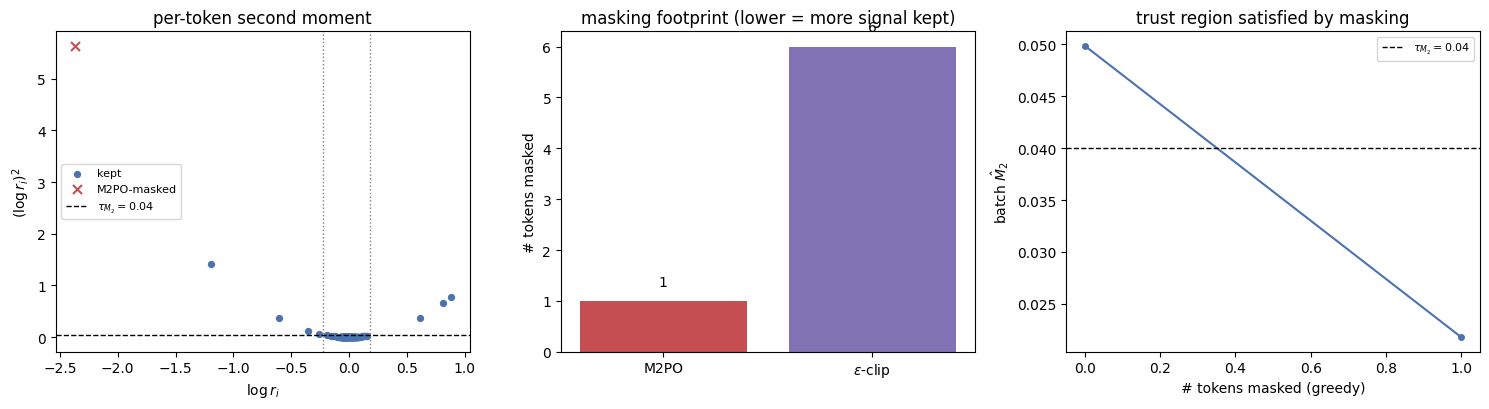

In [4]:
# --- Visualize the mechanism -----------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) Per-token (log r)^2 vs log r: M2PO removes the high-variance tails, eps-clip removes
#     everything past the vertical eps boundaries.
m2_tok = log_r ** 2
ax[0].scatter(log_r[keep_m2po], m2_tok[keep_m2po], s=18, c="#4c72b0", label="kept")
ax[0].scatter(log_r[~keep_m2po], m2_tok[~keep_m2po], s=42, c="#c44e52", marker="x", label="M2PO-masked")
ax[0].axhline(0.04, ls="--", c="k", lw=1, label=r"$\tau_{M_2}=0.04$")
for b in (np.log(1.2), np.log(0.8)):
    ax[0].axvline(b, ls=":", c="gray", lw=1)
ax[0].set_xlabel(r"$\log r_i$"); ax[0].set_ylabel(r"$(\log r_i)^2$")
ax[0].set_title("per-token second moment"); ax[0].legend(fontsize=8)

# (2) How many tokens each trust region silences.
counts = [int((~keep_m2po).sum()), int((~keep_clip).sum())]
ax[1].bar(["M2PO", r"$\epsilon$-clip"], counts, color=["#c44e52", "#8172b3"])
for i, c in enumerate(counts):
    ax[1].text(i, c + 0.3, str(c), ha="center")
ax[1].set_ylabel("# tokens masked"); ax[1].set_title("masking footprint (lower = more signal kept)")

# (3) Greedy descent of batch M2 as tokens are removed, crossing the threshold.
ax[2].plot(np.arange(len(diag["trace"])), diag["trace"], marker="o", ms=4, c="#4c72b0")
ax[2].axhline(0.04, ls="--", c="k", lw=1, label=r"$\tau_{M_2}=0.04$")
ax[2].set_xlabel("# tokens masked (greedy)"); ax[2].set_ylabel(r"batch $\hat M_2$")
ax[2].set_title("trust region satisfied by masking"); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()


## Takeaways & how this maps onto `TreeTrainer`

**What the toy kernel shows**

- M2PO is purely a **token keep-mask** computed from `log_r = logp_theta - logp_behav` and the sign of the advantage. No new reward, no new network.
- The greedy rule removes only the few **highest-variance** trust-region tokens until the batch second moment `M2 = mean(log r)^2` drops below `tau = 0.04`.
- Compared to `eps`-clipping, M2PO masks **far fewer** tokens and **keeps** the informative high-`|r-1|` tokens that clipping would silence — exactly the behavior that lets stale/off-policy data stay useful.
- Masked tokens receive **zero gradient** in the surrogate `J = mean_i keep_i * r_i * A_i`.

**Integration plan for `src/tree_trainer.py` → `_compute_loss`**

1. After OPA rewrites `inputs["advantages"]` to the per-token signal, also need per-token `logp_behav` (the rollout-time / old log-probs already stored by GRPO as `old_per_token_logps`) and the current `per_token_logps`.
2. Compute `log_r = per_token_logps - old_per_token_logps` (already present for the GRPO ratio).
3. Build the M2PO keep-mask over completion tokens (respecting `completion_mask`), grouped at the batch level, then multiply it into the per-token loss in place of (or alongside) the `eps`-clip `min(...)`.
4. Expose `m2po_tau` (default `0.04`) as a trainer arg; gate with a flag so OPA + clip behavior is preserved by default.

The functions above (`m2po_mask`, `trust_region_tokens`, `policy_objective`) are the model-free core to port; the trainer only needs the masked-average loss wired into the existing ratio path.